# House Prices Prediction

## Import libraries


In [54]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


## Load the dataset


In [ ]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "train.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Could not find training data at {TRAIN_PATH}")

dataset_df = pd.read_csv(TRAIN_PATH)
print(f"Full train dataset shape is {dataset_df.shape}")
dataset_df.head(3)


Full train dataset shape is (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


### Cleaning the dataset (Sueda)


We will drop the `Id` column as it is not necessary for model training.

In [9]:
dataset_df = dataset_df.drop(columns="Id")
dataset_df.head(3)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [10]:
dataset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

### Visualization of the numerical data


In [13]:
df_num = dataset_df.select_dtypes(include = ['float64', 'int64'])
df_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


Now let us plot the distribution for all the numerical features.

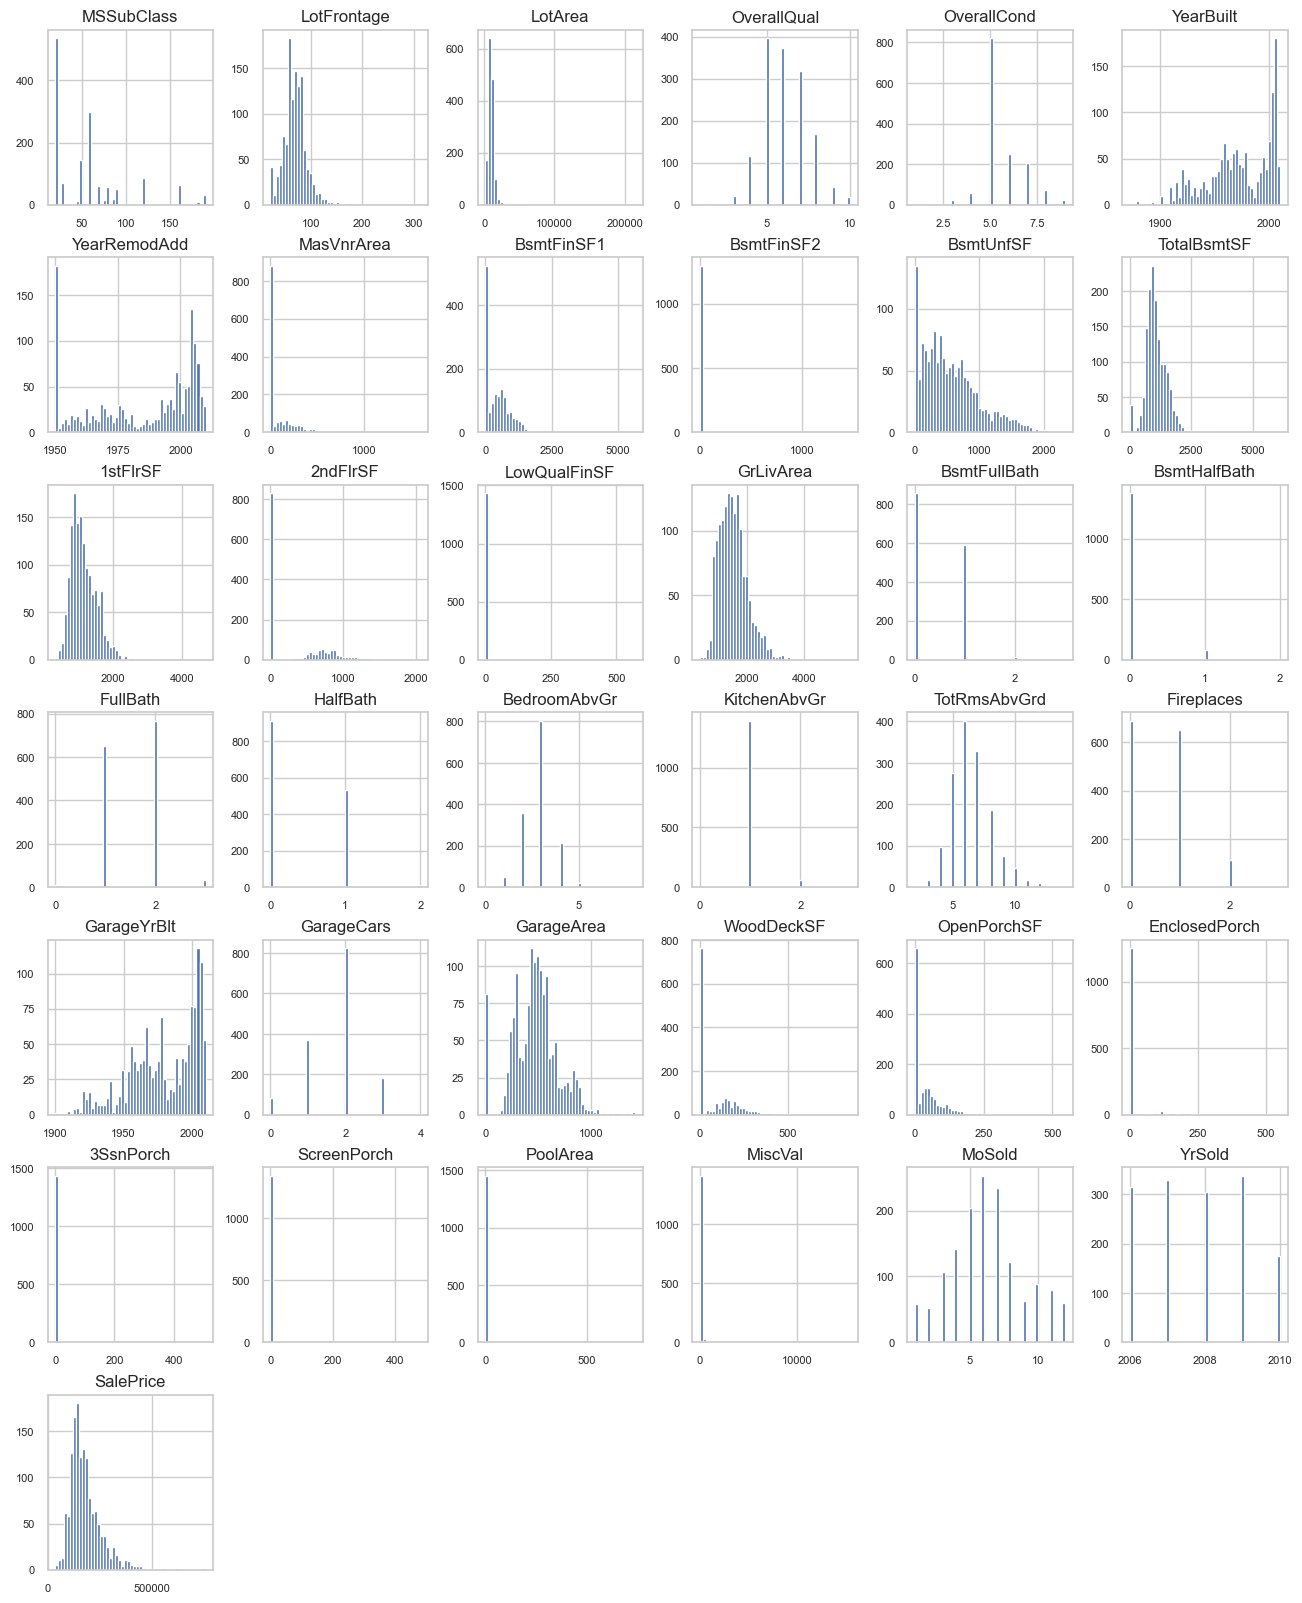

In [14]:
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

### Categorical vs Numerical

In [41]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Numeric features: {len(categorical_features)}")

Numeric features: 36
Numeric features: 43


C:\Users\firas\AppData\Local\Temp\ipykernel_26200\994939355.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()


Now we have to separate the ordinal from pure categorical

In [55]:
# These are categorical but have a logical order
ordinal_features = [
      "Street",
      "Alley",
      "LotShape",
      "Utilities",
      "LandSlope",
      "ExterQual",
      "ExterCond",
      "BsmtQual",
      "BsmtCond",
      "BsmtExposure",
      "BsmtFinType1",
      "BsmtFinType2",
      "HeatingQC",
      "CentralAir",
      "Electrical",
      "KitchenQual",
      "Functional",
      "FireplaceQu",
      "GarageFinish",
      "GarageQual",
      "GarageCond",
      "PavedDrive",
      "PoolQC",
      "Fence",
]

  # Everything categorical but NOT ordinal -> one-hot
onehot_features = [
      col for col in categorical_features
      if col not in ordinal_features
]

In [56]:
quality_order = ["Po", "Fa", "TA", "Gd", "Ex"]
quality_order_with_none = ["None", "Po", "Fa", "TA", "Gd", "Ex"]

ordinal_categories = [
      ["Grvl", "Pave"],                          # Street
      ["None", "Grvl", "Pave"],                  # Alley
      ["IR3", "IR2", "IR1", "Reg"],              # LotShape
      ["ELO", "NoSeWa", "NoSewr", "AllPub"],     # Utilities
      ["Sev", "Mod", "Gtl"],                     # LandSlope

      quality_order,                             # ExterQual
      quality_order,                             # ExterCond
      quality_order_with_none,                   # BsmtQual
      quality_order_with_none,                   # BsmtCond

      ["None", "No", "Mn", "Av", "Gd"],          # BsmtExposure
      ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],  # BsmtFinType1
      ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],  # BsmtFinType2

      quality_order,                             # HeatingQC
      ["N", "Y"],                                # CentralAir
      ["Mix", "FuseP", "FuseF", "FuseA", "SBrkr"], # Electrical
      quality_order,                             # KitchenQual

      ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"], # Functional

      quality_order_with_none,                   # FireplaceQu
      ["None", "Unf", "RFn", "Fin"],             # GarageFinish
      quality_order_with_none,                   # GarageQual
      quality_order_with_none,                   # GarageCond

      ["N", "P", "Y"],                           # PavedDrive
      ["None", "Fa", "TA", "Gd", "Ex"],          # PoolQC
      ["None", "MnWw", "GdWo", "MnPrv", "GdPrv"], # Fence
]

In [57]:
numeric_transformer = Pipeline(
      steps=[
          ("imputer", SimpleImputer(strategy="median"))
      ]
)

ordinal_transformer = Pipeline(
      steps=[
          ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
          ("ordinal", OrdinalEncoder(
              categories=ordinal_categories,
              handle_unknown="use_encoded_value",
              unknown_value=-1
          ))
      ]
)

onehot_transformer = Pipeline(
      steps=[
          ("imputer", SimpleImputer(strategy="most_frequent")),
          ("onehot", OneHotEncoder(handle_unknown="ignore"))
      ]
)

preprocessor = ColumnTransformer(
      transformers=[
          ("num", numeric_transformer, numeric_features),
          ("ord", ordinal_transformer, ordinal_features),
          ("cat", onehot_transformer, onehot_features),
      ]
)

In [58]:
print(f"Ordinal categorical features: {len(ordinal_features)}")
print(f"One-hot categorical features: {len(onehot_features)}")

Ordinal categorical features: 24
One-hot categorical features: 19


### Prepare the train - test data

In [ ]:
X = dataset_df.drop(columns="SalePrice")
y = dataset_df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print(f"Training set: {len(X_train)} samples, {X_train.shape[1]} features")
print(f"Validation set: {len(X_valid)} samples")


Training set: 1095 samples, 79 features
Validation set: 365 samples


## Model E (Lineal Regression)

In [ ]:
forest = rf_model.named_steps["model"]
first_tree = forest.estimators_[0]

print(f"Number of trees: {len(forest.estimators_)}")
print(f"First tree depth: {first_tree.get_depth()}")
print(f"First tree leaves: {first_tree.get_n_leaves()}")


Number of trees: 500
First tree depth: 29
First tree leaves: 663


### Evaluate the model on the validation dataset


In [ ]:
valid_predictions = rf_model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, valid_predictions))
mae = mean_absolute_error(y_valid, valid_predictions)
r2 = r2_score(y_valid, valid_predictions)
rmsle = np.sqrt(
    mean_squared_error(
        np.log1p(y_valid),
        np.log1p(np.maximum(valid_predictions, 0)),
    )
)

metrics = pd.Series(
    {
        "RMSE": rmse,
        "MAE": mae,
        "RMSLE": rmsle,
        "R2": r2,
    }
)
metrics.round(4)


RMSE     26840.2447
MAE      16781.4330
RMSLE        0.1429
R2           0.8972
dtype: float64

We can also inspect the prediction errors visually.


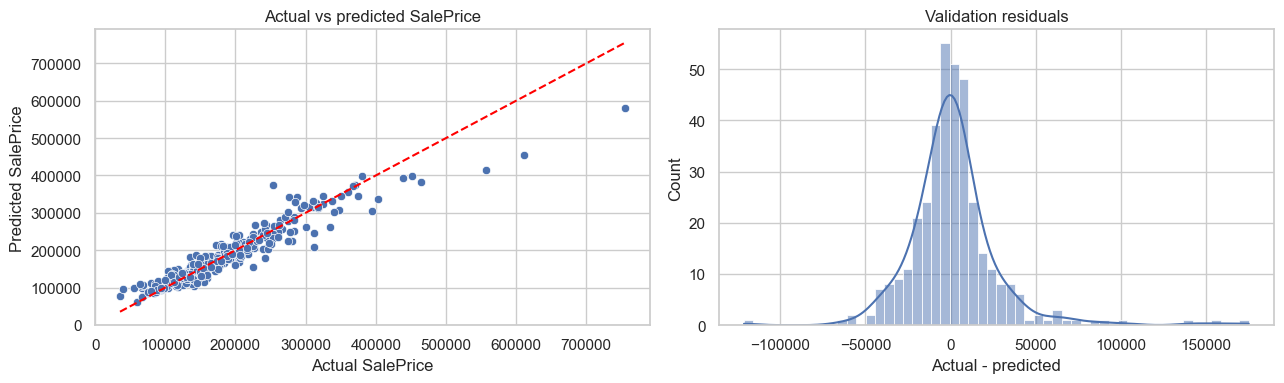

In [ ]:
residuals = y_valid - valid_predictions

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(x=y_valid, y=valid_predictions, ax=axes[0])
axes[0].plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], color="red", linestyle="--")
axes[0].set_title("Actual vs predicted SalePrice")
axes[0].set_xlabel("Actual SalePrice")
axes[0].set_ylabel("Predicted SalePrice")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Validation residuals")
axes[1].set_xlabel("Actual - predicted")

plt.tight_layout()
plt.show()


Now, let us print the validation metrics clearly.


In [ ]:
for name, value in metrics.items():
    print(f"{name}: {value:,.4f}")


RMSE: 26,840.2447
MAE: 16,781.4330
RMSLE: 0.1429
R2: 0.8972


### Variable importances

Permutation importance measures how much validation performance drops when a feature is randomly shuffled. This works directly with the full pipeline and avoids fragile model-specific TensorFlow code.


In [ ]:
importance_result = permutation_importance(
    rf_model,
    X_valid,
    y_valid,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

feature_importance_df = pd.DataFrame(
    {
        "feature": X_valid.columns,
        "importance_mean": importance_result.importances_mean,
        "importance_std": importance_result.importances_std,
    }
).sort_values("importance_mean", ascending=False)

feature_importance_df.head(15)


,feature,importance_mean,importance_std
16,OverallQual,0.446945,0.047627
45,GrLivArea,0.119691,0.008457
43,2ndFlrSF,0.025350,0.000337
37,TotalBsmtSF,0.021756,0.002781
60,GarageCars,0.017117,0.003331
42,1stFlrSF,0.014851,0.003378
33,BsmtFinSF1,0.014268,0.001299
3,LotArea,0.008618,0.001119
61,GarageArea,0.005418,0.001196
29,BsmtQual,0.004553,0.001557


The table above is sorted from the most useful original input feature to the least useful for this validation split.


In [ ]:
feature_importance_df.head(20)


,feature,importance_mean,importance_std
16,OverallQual,0.446945,0.047627
45,GrLivArea,0.119691,0.008457
43,2ndFlrSF,0.025350,0.000337
37,TotalBsmtSF,0.021756,0.002781
60,GarageCars,0.017117,0.003331
42,1stFlrSF,0.014851,0.003378
33,BsmtFinSF1,0.014268,0.001299
3,LotArea,0.008618,0.001119
61,GarageArea,0.005418,0.001196
29,BsmtQual,0.004553,0.001557


Plot the top variable importances using Matplotlib.


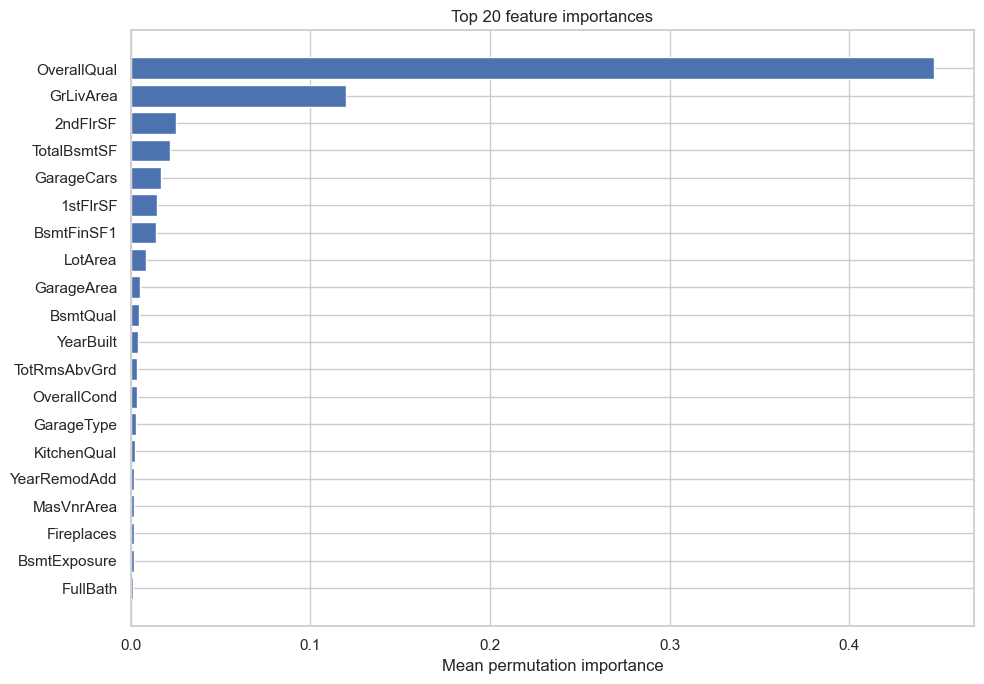

In [ ]:
top_features = feature_importance_df.head(20).sort_values("importance_mean")

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance_mean"])
plt.xlabel("Mean permutation importance")
plt.title("Top 20 feature importances")
plt.tight_layout()
plt.show()


## Model F


## Model S

## Inspect models accuracy


# Submission

Finally, predict on the competition test data using the local `data/test.csv` file and save a Kaggle-compatible submission file in the project root.


In [28]:
test_data = pd.read_csv(TEST_PATH)
submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

ids = test_data.pop("Id")
test_predictions = rf_model.predict(test_data)

submission["Id"] = ids
submission["SalePrice"] = test_predictions

output_path = PROJECT_ROOT / "submission.csv"
submission.to_csv(output_path, index=False)

print(f"Saved submission to: {output_path}")
submission.head()


Saved submission to: c:\Users\firas\OneDrive - UPV\Escritorio\AI course\Machine Learning Unsupervised\Project\submission.csv


,Id,SalePrice
0,1461,128188.850
1,1462,154078.528
2,1463,182871.972
3,1464,184926.190
4,1465,204841.100


In [29]:
submission.describe()


,Id,SalePrice
count,1459.000000,1459.000000
mean,2190.000000,178596.873341
std,421.321334,71288.509256
min,1461.000000,60082.000000
25%,1825.500000,129952.052000
50%,2190.000000,158245.844000
75%,2554.500000,208646.734000
max,2919.000000,507072.314000
